In [44]:
import json
import os
import re
from datetime import datetime

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CSV_BASE_LABEL = "CSV Baseline"
CSV_PIE_LABEL = "CSV IntEl"
JSON_BASE_LABEL = "JSON Baseline"
JSON_PIE_LABEL = "JSON IntEl"

SUITE_ORDER = [CSV_BASE_LABEL, CSV_PIE_LABEL, JSON_BASE_LABEL, JSON_PIE_LABEL]

CSV_BID_FILE_SIZE = 6678514674        # bytes
CSV_PERSON_FILE_SIZE = 880941057      # bytes
JSON_BID_FILE_SIZE = 15878100724      # bytes
JSON_PERSON_FILE_SIZE = 1300941057    # bytes

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 9,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

def style_axis(ax):
    ax.grid(True, axis="y", color="#D8D8D8", linestyle="-", linewidth=0.45, alpha=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)

def add_panel_label(ax, label):
    ax.text(0.02, 0.96, label, transform=ax.transAxes, ha="left", va="top", fontweight="bold")

def add_bottom_right_legend(ax, ncol=1):
    ax.legend(loc="lower right", ncol=ncol, frameon=True, framealpha=0.92, facecolor="white", edgecolor="none")

SUITE_COLORS = {
    CSV_BASE_LABEL: "#0072B2",
    CSV_PIE_LABEL: "#009E73",
    JSON_BASE_LABEL: "#D55E00",
    JSON_PIE_LABEL: "#CC79A7",
}
SUITE_HATCH = {
    CSV_BASE_LABEL: "",
    CSV_PIE_LABEL: "//",
    JSON_BASE_LABEL: "",
    JSON_PIE_LABEL: "//",
}
SUITE_MARKERS = {
    CSV_BASE_LABEL: "o",
    CSV_PIE_LABEL: "^",
    JSON_BASE_LABEL: "o",
    JSON_PIE_LABEL: "^",
}

suite_order = SUITE_ORDER
suite_colors = SUITE_COLORS
suite_hatch = SUITE_HATCH
suite_markers = SUITE_MARKERS

def shorten_query(q):
    q = re.sub(r"\s+INTO\s+\w+", "", q, flags=re.IGNORECASE)
    q = re.sub(r'VARSIZED\("([^"]+)"\)', r'"\1"', q)
    q = re.sub(r'INT32\((\d+)\)', r'\1', q)
    q = re.sub(r'FLOAT64\(([\d.]+)\)', r'\1', q)
    return re.sub(r'\s+', ' ', q).strip()

def get_file_size(query, suite_name):
    is_json = "json" in suite_name.lower()
    if "from bid" in query.lower():
        return JSON_BID_FILE_SIZE if is_json else CSV_BID_FILE_SIZE
    return JSON_PERSON_FILE_SIZE if is_json else CSV_PERSON_FILE_SIZE

def load_suite(filepath, suite_name):
    with open(filepath) as f:
        data = json.load(f)
    rows = []
    for r in data:
        if r.get("status") != "Stopped" or not r.get("started") or not r.get("stopped"):
            continue
        started = datetime.strptime(r["started"], "%Y-%m-%d %H:%M:%S.%f")
        stopped = datetime.strptime(r["stopped"], "%Y-%m-%d %H:%M:%S.%f")
        exec_time = (stopped - started).total_seconds()
        query = shorten_query(r["query"].strip())
        file_size = get_file_size(query, suite_name)
        rows.append({
            "suite": suite_name,
            "query": query,
            "threads": r["threads_number"],
            "exec_time_s": exec_time,
            "throughput_MBs": file_size / exec_time / (1024 * 1024),
        })
    return rows

rows = []
rows += load_suite("results/baseline_results_1776936990.json", CSV_BASE_LABEL)
rows += load_suite("results/optimized_results_1776941720.json", CSV_PIE_LABEL)
rows += load_suite("results/baseline-json_results_1776945082.json", JSON_BASE_LABEL)
rows += load_suite("results/optimized-json_results_1776951425.json", JSON_PIE_LABEL)

rows += load_suite("results/baseline_results_1776905115.json", CSV_BASE_LABEL)
rows += load_suite("results/optimized_results_1776906324.json", CSV_PIE_LABEL)
rows += load_suite("results/baseline-json_results_1776907191.json", JSON_BASE_LABEL)
rows += load_suite("results/optimized-json_results_1776908815.json", JSON_PIE_LABEL)
df = pd.DataFrame(rows)

queries = sorted(df["query"].unique())
query_labels = {q: f"Q{i + 1}" for i, q in enumerate(queries)}
thread_counts = sorted(df["threads"].unique())
suite_order = SUITE_ORDER

print(f"Records: {len(df)}")
print(f"Suites: {sorted(df['suite'].unique())}")
print(f"Threads: {thread_counts}")
print(f"Queries: {queries}")
df

Records: 360
Suites: ['CSV Baseline', 'CSV IntEl', 'JSON Baseline', 'JSON IntEl']
Threads: [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64)]
Queries: ['SELECT auctionId FROM bid WHERE bidder == 1001', 'SELECT auctionId FROM bid WHERE bidder == 1001 OR bidder == 1002', 'SELECT auctionId FROM bid WHERE timestamp == UINT64(1746560847870)']


,suite,query,threads,exec_time_s,throughput_MBs
0,CSV Baseline,SELECT auctionId FROM bid WHERE bidder == 1001,2,182.830,34.836339
1,CSV Baseline,SELECT auctionId FROM bid WHERE bidder == 1001,2,183.520,34.705361
2,CSV Baseline,SELECT auctionId FROM bid WHERE bidder == 1001,2,182.839,34.834625
3,CSV Baseline,SELECT auctionId FROM bid WHERE bidder == 1001,2,182.868,34.829100
4,CSV Baseline,SELECT auctionId FROM bid WHERE timestamp == U...,2,182.566,34.886714
...,...,...,...,...,...
355,JSON IntEl,SELECT auctionId FROM bid WHERE timestamp == U...,32,17.164,882.226570
356,JSON IntEl,SELECT auctionId FROM bid WHERE bidder == 1001...,32,17.064,887.396675
357,JSON IntEl,SELECT auctionId FROM bid WHERE bidder == 1001,64,25.447,595.061770
358,JSON IntEl,SELECT auctionId FROM bid WHERE timestamp == U...,64,18.210,831.550623


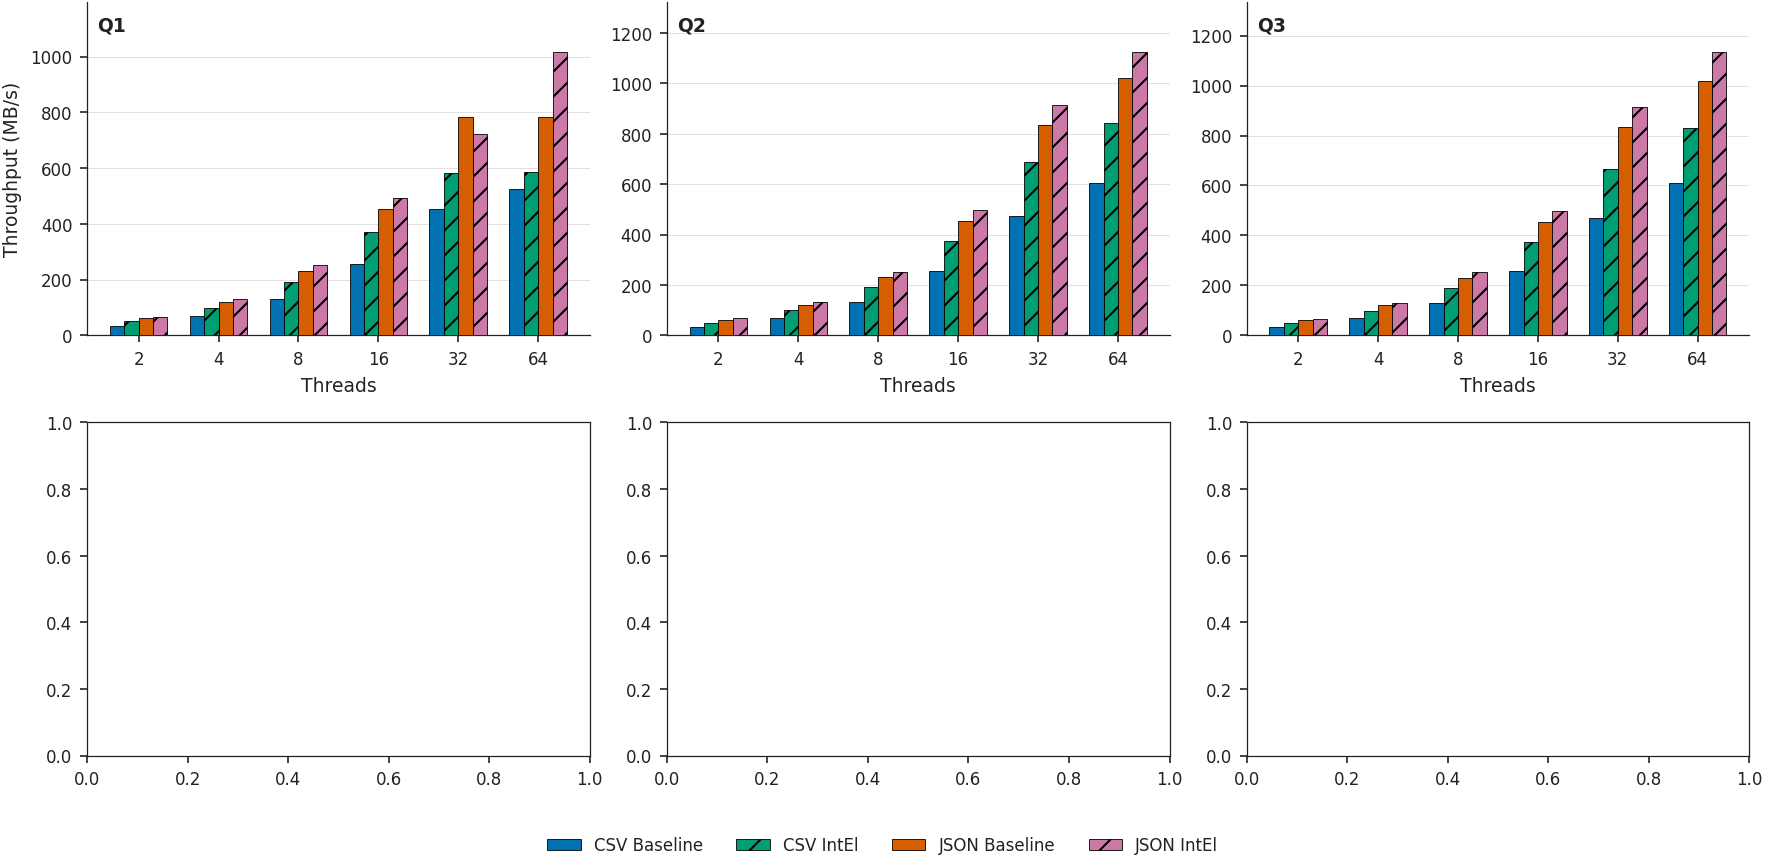

In [45]:
# Grouped bar chart: median throughput per query and thread count
n_suites = len(suite_order)
bar_width = 0.18
x = np.arange(len(thread_counts))

with mpl.rc_context(thesis_rc):
    fig, axes = plt.subplots(2, 3, figsize=(12.0, 5.8), sharey=False, squeeze=False)

    for idx, q in enumerate(queries):
        row, col = divmod(idx, 3)
        ax = axes[row][col]

        for j, suite in enumerate(suite_order):
            s_data = df[(df["query"] == q) & (df["suite"] == suite)]
            vals = s_data.groupby("threads")["throughput_MBs"].median().reindex(thread_counts)
            offset = (j - (n_suites - 1) / 2) * bar_width
            ax.bar(
                x + offset,
                vals.values,
                bar_width,
                label=suite,
                color=suite_colors[suite],
                edgecolor="black",
                linewidth=0.4,
                hatch=suite_hatch[suite],
                zorder=3,
            )

        ax.set_xlabel("Threads")
        ax.set_ylabel("Throughput (MB/s)" if col == 0 else "")
        add_panel_label(ax, query_labels[q])
        ax.set_xticks(x)
        ax.set_xticklabels(thread_counts)
        ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
        style_axis(ax)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    fig.savefig(os.path.join(PLOTS_DIR, "raw_comparison_per_query_throughput.pdf"))
    plt.show()

In [46]:
# Aggregation table: median throughput per suite/query/thread and derived speedups
run_agg = (
    df.groupby(["suite", "query", "threads"], as_index=False)["throughput_MBs"]
    .median()
)

throughput_pivot = run_agg.pivot_table(
    index=["query", "threads"],
    columns="suite",
    values="throughput_MBs",
)
throughput_pivot = throughput_pivot[suite_order]
throughput_pivot["CSV speedup"] = throughput_pivot[CSV_PIE_LABEL] / throughput_pivot[CSV_BASE_LABEL]
throughput_pivot["JSON speedup"] = throughput_pivot[JSON_PIE_LABEL] / throughput_pivot[JSON_BASE_LABEL]
throughput_pivot.round(2)

suite                                                       CSV Baseline  \
query                                              threads                 
SELECT auctionId FROM bid WHERE bidder == 1001     2               34.83   
                                                   4               67.84   
                                                   8              130.41   
                                                   16             255.59   
                                                   32             452.93   
                                                   64             525.03   
SELECT auctionId FROM bid WHERE bidder == 1001 ... 2               34.83   
                                                   4               67.92   
                                                   8              130.60   
                                                   16             257.28   
                                                   32             474.53   
                                                   64             605.20   
SELECT auctionId FROM bid WHERE timestamp == UI... 2               34.89   
                                                   4               67.90   
                                                   8              130.60   
                                                   16             256.98   
                                                   32             468.84   
                                                   64             611.01   

suite                                                       CSV IntEl  \
query                                              threads              
SELECT auctionId FROM bid WHERE bidder == 1001     2            50.45   
                                                   4            98.11   
                                                   8           189.77   
                                                   16          371.20   
                                                   32          583.15   
                                                   64          586.10   
SELECT auctionId FROM bid WHERE bidder == 1001 ... 2            50.72   
                                                   4            98.68   
                                                   8           190.29   
                                                   16          373.78   
                                                   32          686.18   
                                                   64          844.49   
SELECT auctionId FROM bid WHERE timestamp == UI... 2            50.37   
                                                   4            98.11   
                                                   8           188.87   
                                                   16          373.14   
                                                   32          667.69   
                                                   64          828.88   

suite                                                       JSON Baseline  \
query                                              threads                  
SELECT auctionId FROM bid WHERE bidder == 1001     2                61.31   
                                                   4               119.59   
                                                   8               229.83   
                                                   16              452.77   
                                                   32              781.99   
                                                   64              784.34   
SELECT auctionId FROM bid WHERE bidder == 1001 ... 2                61.46   
                                                   4               119.23   
                                                   8               230.13   
                                                   16              455.54   
                                                   32              836.79   
                 

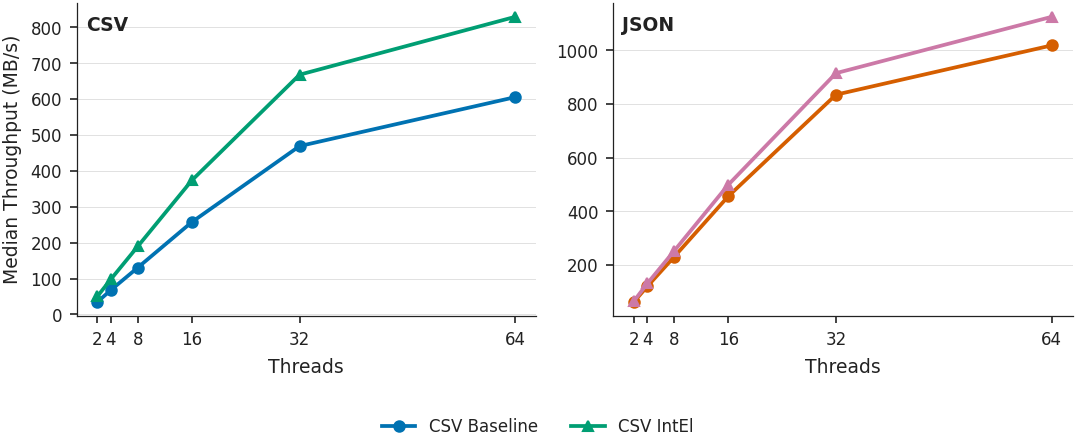

In [47]:
# Aggregate throughput plot: median across queries, split by input format
suite_to_format = {
    CSV_BASE_LABEL: "CSV",
    CSV_PIE_LABEL: "CSV",
    JSON_BASE_LABEL: "JSON",
    JSON_PIE_LABEL: "JSON",
}

format_summary = run_agg.copy()
format_summary["format"] = format_summary["suite"].map(suite_to_format)
format_summary = (
    format_summary.groupby(["format", "suite", "threads"], as_index=False)["throughput_MBs"]
    .median()
)

with mpl.rc_context(thesis_rc):
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), sharex=True, sharey=False, squeeze=False)

    for col, fmt in enumerate(["CSV", "JSON"]):
        ax = axes[0][col]
        fmt_suites = [CSV_BASE_LABEL, CSV_PIE_LABEL] if fmt == "CSV" else [JSON_BASE_LABEL, JSON_PIE_LABEL]
        fmt_data = format_summary[format_summary["format"] == fmt]

        for suite in fmt_suites:
            subset = fmt_data[fmt_data["suite"] == suite].set_index("threads").reindex(thread_counts)
            ax.plot(
                thread_counts,
                subset["throughput_MBs"].to_numpy(dtype=float),
                marker=suite_markers[suite],
                markersize=5.0,
                linewidth=1.8,
                color=suite_colors[suite],
                label=suite,
            )

        add_panel_label(ax, fmt)
        ax.set_xlabel("Threads")
        ax.set_ylabel("Median Throughput (MB/s)" if col == 0 else "")
        ax.set_xticks(thread_counts)
        style_axis(ax)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04))
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    fig.savefig(os.path.join(PLOTS_DIR, "raw_comparison_aggregate_throughput.pdf"))
    plt.show()

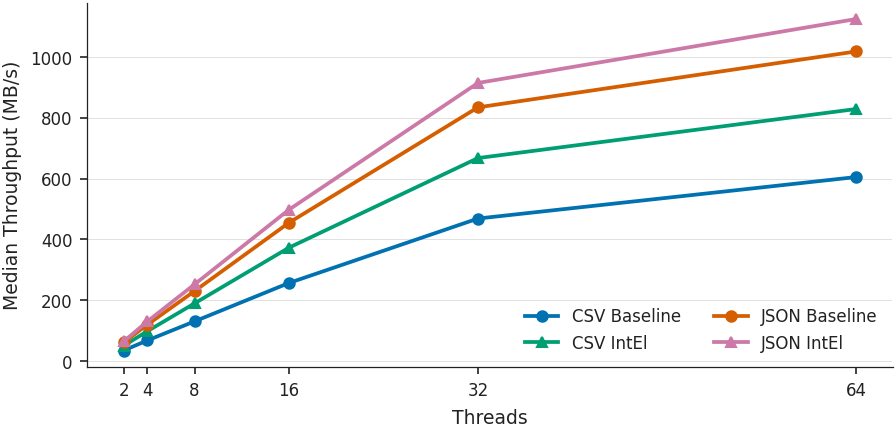

In [48]:
# Aggregate throughput plot: median across queries for all four suites
overall_throughput_summary = (
    run_agg.groupby(["suite", "threads"], as_index=False)["throughput_MBs"]
    .median()
)

with mpl.rc_context(thesis_rc):
    fig, ax = plt.subplots(figsize=(6.2, 3.1))

    for suite in suite_order:
        subset = overall_throughput_summary[overall_throughput_summary["suite"] == suite].set_index("threads").reindex(thread_counts)
        ax.plot(
            thread_counts,
            subset["throughput_MBs"].to_numpy(dtype=float),
            marker=suite_markers[suite],
            markersize=5.0,
            linewidth=1.8,
            color=suite_colors[suite],
            label=suite,
        )

    ax.set_xlabel("Threads")
    ax.set_ylabel("Median Throughput (MB/s)")
    ax.set_xticks(thread_counts)
    style_axis(ax)
    add_bottom_right_legend(ax, ncol=2)

    fig.tight_layout()
    fig.savefig(os.path.join(PLOTS_DIR, "raw_comparison_aggregate_throughput_all_suites.pdf"))
    plt.show()

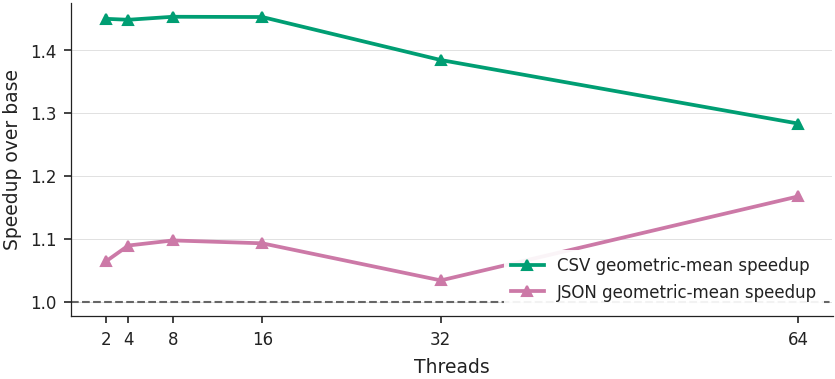

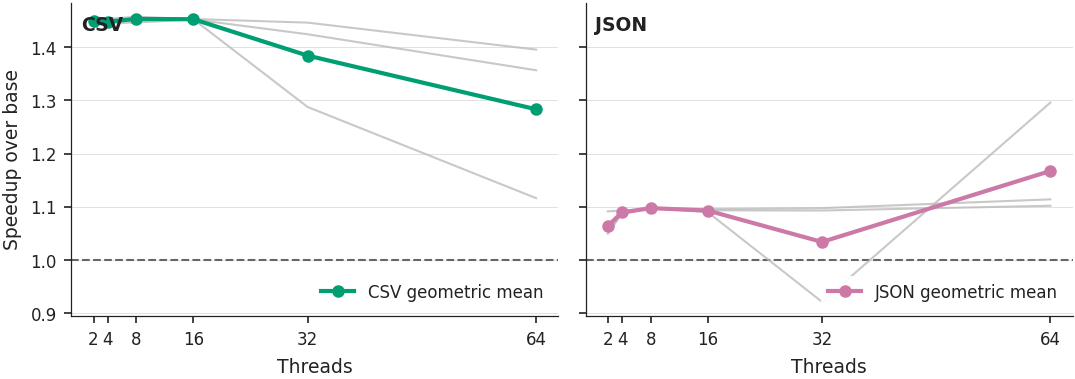

suite,threads,CSV speedup,JSON speedup
0,2,1.450,1.064
1,4,1.448,1.089
2,8,1.453,1.098
3,16,1.452,1.093
4,32,1.384,1.034
5,64,1.283,1.167


In [49]:
# Speedup plots: geometric-mean aggregate and per-query overlays
def geom_mean(series):
    series = series.dropna()
    return np.exp(np.log(series).mean()) if len(series) else np.nan

speedup_summary = (
    throughput_pivot.reset_index()
    .groupby("threads")[["CSV speedup", "JSON speedup"]]
    .agg(geom_mean)
    .reset_index()
)

with mpl.rc_context(thesis_rc):
    fig, ax = plt.subplots(figsize=(5.8, 3.0))
    ax.axhline(1.0, color="#666666", linewidth=1.0, linestyle="--", zorder=1)
    ax.plot(
        speedup_summary["threads"],
        speedup_summary["CSV speedup"],
        marker=suite_markers[CSV_PIE_LABEL],
        markersize=5.0,
        linewidth=1.8,
        color=suite_colors[CSV_PIE_LABEL],
        label="CSV geometric-mean speedup",
        zorder=3,
    )
    ax.plot(
        speedup_summary["threads"],
        speedup_summary["JSON speedup"],
        marker=suite_markers[JSON_PIE_LABEL],
        markersize=5.0,
        linewidth=1.8,
        color=suite_colors[JSON_PIE_LABEL],
        label="JSON geometric-mean speedup",
        zorder=3,
    )
    ax.set_xlabel("Threads")
    ax.set_ylabel("Speedup over base")
    ax.set_xticks(thread_counts)
    style_axis(ax)
    add_bottom_right_legend(ax)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    fig.savefig(os.path.join(PLOTS_DIR, "raw_comparison_geomean_speedup.pdf"))
    plt.show()

speedup_by_query = throughput_pivot.reset_index()[["query", "threads", "CSV speedup", "JSON speedup"]]

with mpl.rc_context(thesis_rc):
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), sharex=True, sharey=True, squeeze=False)

    for col, (metric, fmt, color) in enumerate([
        ("CSV speedup", "CSV", suite_colors[CSV_PIE_LABEL]),
        ("JSON speedup", "JSON", suite_colors[JSON_PIE_LABEL]),
    ]):
        ax = axes[0][col]
        ax.axhline(1.0, color="#666666", linewidth=1.0, linestyle="--", zorder=1)

        for q in queries:
            subset = speedup_by_query[speedup_by_query["query"] == q].set_index("threads").reindex(thread_counts)
            ax.plot(
                thread_counts,
                subset[metric].to_numpy(dtype=float),
                color="#BBBBBB",
                linewidth=1.0,
                alpha=0.8,
                zorder=2,
            )

        ax.plot(
            speedup_summary["threads"],
            speedup_summary[metric],
            marker="o",
            markersize=5.0,
            linewidth=2.0,
            color=color,
            label=f"{fmt} geometric mean",
            zorder=3,
        )

        add_panel_label(ax, fmt)
        ax.set_xlabel("Threads")
        ax.set_ylabel("Speedup over base" if col == 0 else "")
        ax.set_xticks(thread_counts)
        style_axis(ax)
        add_bottom_right_legend(ax)

    fig.tight_layout(rect=(0, 0.08, 1, 1))
    fig.savefig(os.path.join(PLOTS_DIR, "raw_comparison_per_query_speedup.pdf"))
    plt.show()

speedup_summary.round(3)

In [50]:
# LaTeX per-query throughput table (booktabs + multirow; no siunitx).
# Requires in thesis preamble: \\usepackage{booktabs,multirow}

tbl = throughput_pivot[[
    CSV_BASE_LABEL,
    CSV_PIE_LABEL,
    JSON_BASE_LABEL,
    JSON_PIE_LABEL,
]].copy()
tbl["CSV speedup"] = tbl[CSV_PIE_LABEL] / tbl[CSV_BASE_LABEL]
tbl["JSON speedup"] = tbl[JSON_PIE_LABEL] / tbl[JSON_BASE_LABEL]

queries_sorted = sorted({q for q, _ in tbl.index})
query_labels = {q: f"Q{i+1}" for i, q in enumerate(queries_sorted)}

def latex_escape(s: str) -> str:
    repl = {
        "\\": r"\textbackslash{}",
        "&":  r"\&",
        "%":  r"\%",
        "$":  r"\$",
        "#":  r"\#",
        "_":  r"\_",
        "{":  r"\{",
        "}":  r"\}",
        "~":  r"\textasciitilde{}",
        "^":  r"\textasciicircum{}",
        '"':  r"\textquotedbl{}",
    }
    return "".join(repl.get(c, c) for c in s)

def fmt_tp(v): return "--" if pd.isna(v) else f"{v:.0f}"
def fmt_sp(v): return "--" if pd.isna(v) else f"{v:.2f}"

legend_lines = []
legend_lines.append(r"\begin{table}[ht]")
legend_lines.append(r"  \centering")
legend_lines.append(r"  \small")
legend_lines.append(r"  \caption{Query definitions used in Table~\ref{tab:raw-comparison-per-query}.}")
legend_lines.append(r"  \label{tab:raw-comparison-queries}")
legend_lines.append(r"  \begin{tabular}{ll}")
legend_lines.append(r"    \toprule")
legend_lines.append(r"    Label & Query \\")
legend_lines.append(r"    \midrule")
for q in queries_sorted:
    legend_lines.append(f"    {query_labels[q]} & \texttt{{{latex_escape(q)}}} \\")
legend_lines.append(r"    \bottomrule")
legend_lines.append(r"  \end{tabular}")
legend_lines.append(r"\end{table}")
legend_str = "\n".join(legend_lines)

lines = []
lines.append(r"\begin{table}[ht]")
lines.append(r"  \centering")
lines.append(r"  \small")
lines.append(r"  \caption{Median throughput (MB/s) and speedup per query and thread count for \texttt{raw-comparison}. Speedup is Numerical Value Elision/base. Query labels defined in Table~\ref{tab:raw-comparison-queries}.}")
lines.append(r"  \label{tab:raw-comparison-per-query}")
lines.append(r"  \begin{tabular}{llrrrrrr}")
lines.append(r"    \toprule")
lines.append(r"    \multirow{2}{*}{Query} & \multirow{2}{*}{Threads} & \multicolumn{3}{c}{CSV (MB/s)} & \multicolumn{3}{c}{JSON (MB/s)} \\")
lines.append(r"    \cmidrule(lr){3-5} \cmidrule(lr){6-8}")
lines.append(r"     &  & base & Numerical Value Elision & speedup & base & Numerical Value Elision & speedup \\")
lines.append(r"    \midrule")

for qi, q in enumerate(queries_sorted):
    sub = tbl.loc[q]
    n = len(sub)
    label = query_labels[q]
    q_cell = rf"\multirow{{{n}}}{{*}}{{{label}}}"
    for ri, (threads, row) in enumerate(sub.iterrows()):
        cells = [
            q_cell if ri == 0 else "",
            str(int(threads)),
            fmt_tp(row.get(CSV_BASE_LABEL)),
            fmt_tp(row.get(CSV_PIE_LABEL)),
            fmt_sp(row.get("CSV speedup")),
            fmt_tp(row.get(JSON_BASE_LABEL)),
            fmt_tp(row.get(JSON_PIE_LABEL)),
            fmt_sp(row.get("JSON speedup")),
        ]
        lines.append("    " + " & ".join(cells) + r" \\")
    if qi < len(queries_sorted) - 1:
        lines.append(r"    \midrule")

lines.append(r"    \bottomrule")
lines.append(r"  \end{tabular}")
lines.append(r"\end{table}")

full_tex = legend_str + "\n\n" + "\n".join(lines)
print(full_tex)

os.makedirs("results", exist_ok=True)
with open("results/per_query_table.tex", "w") as f:
    f.write(full_tex + "\n")
print("\n-> saved to results/per_query_table.tex")


\begin{table}[ht]
  \centering
  \small
  \caption{Query definitions used in Table~\ref{tab:raw-comparison-per-query}.}
  \label{tab:raw-comparison-queries}
  \begin{tabular}{ll}
    \toprule
    Label & Query \\
    \midrule
    Q1 & 	exttt{SELECT auctionId FROM bid WHERE bidder == 1001} \
    Q2 & 	exttt{SELECT auctionId FROM bid WHERE bidder == 1001 OR bidder == 1002} \
    Q3 & 	exttt{SELECT auctionId FROM bid WHERE timestamp == UINT64(1746560847870)} \
    \bottomrule
  \end{tabular}
\end{table}

\begin{table}[ht]
  \centering
  \small
  \caption{Median throughput (MB/s) and speedup per query and thread count for \texttt{raw-comparison}. Speedup is Numerical Value Elision/base. Query labels defined in Table~\ref{tab:raw-comparison-queries}.}
  \label{tab:raw-comparison-per-query}
  \begin{tabular}{llrrrrrr}
    \toprule
    \multirow{2}{*}{Query} & \multirow{2}{*}{Threads} & \multicolumn{3}{c}{CSV (MB/s)} & \multicolumn{3}{c}{JSON (MB/s)} \\
    \cmidrule(lr){3-5} \cmidrule(lr){6-

wrote plots/raw_comparison_line_throughput_q1.pdf


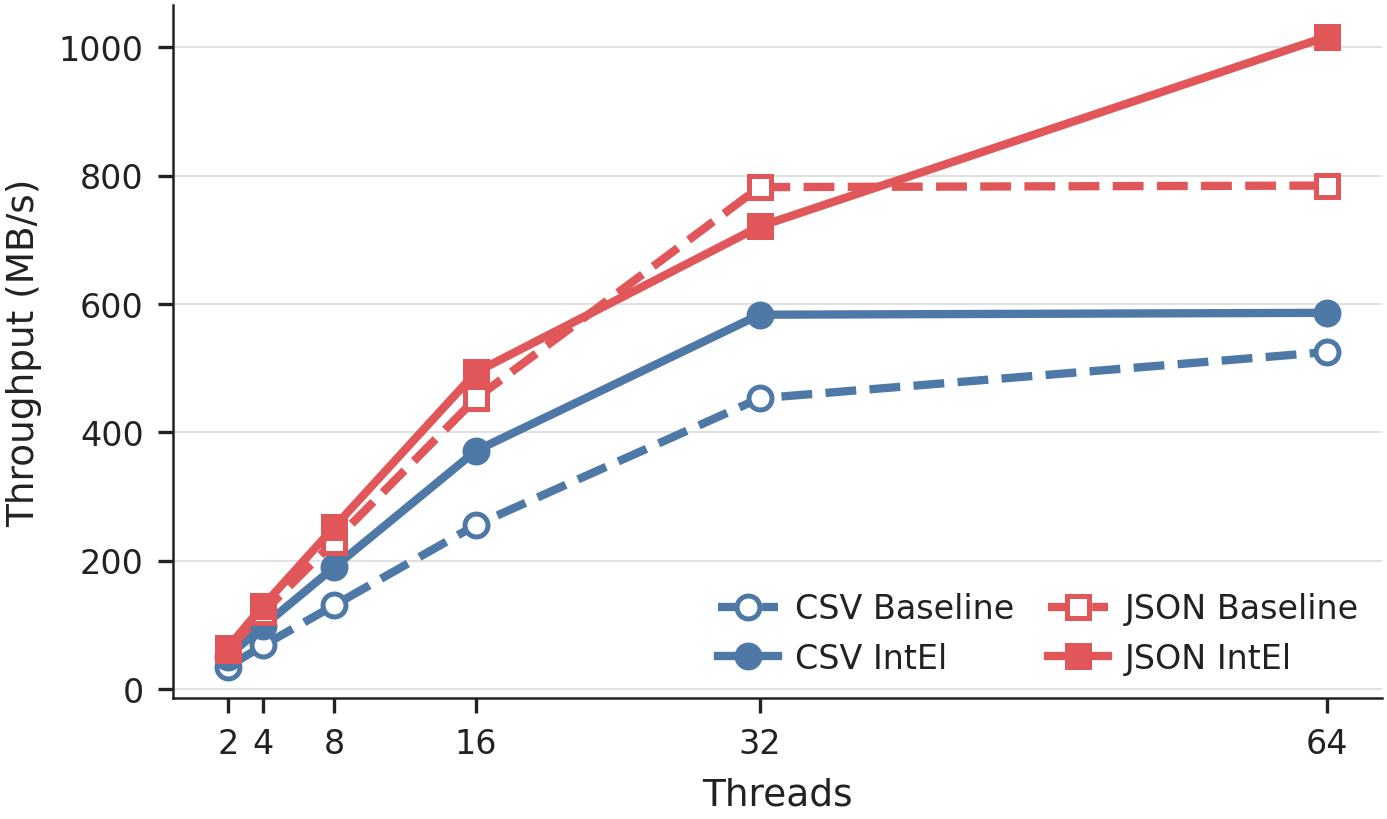

wrote plots/raw_comparison_line_throughput_q2.pdf


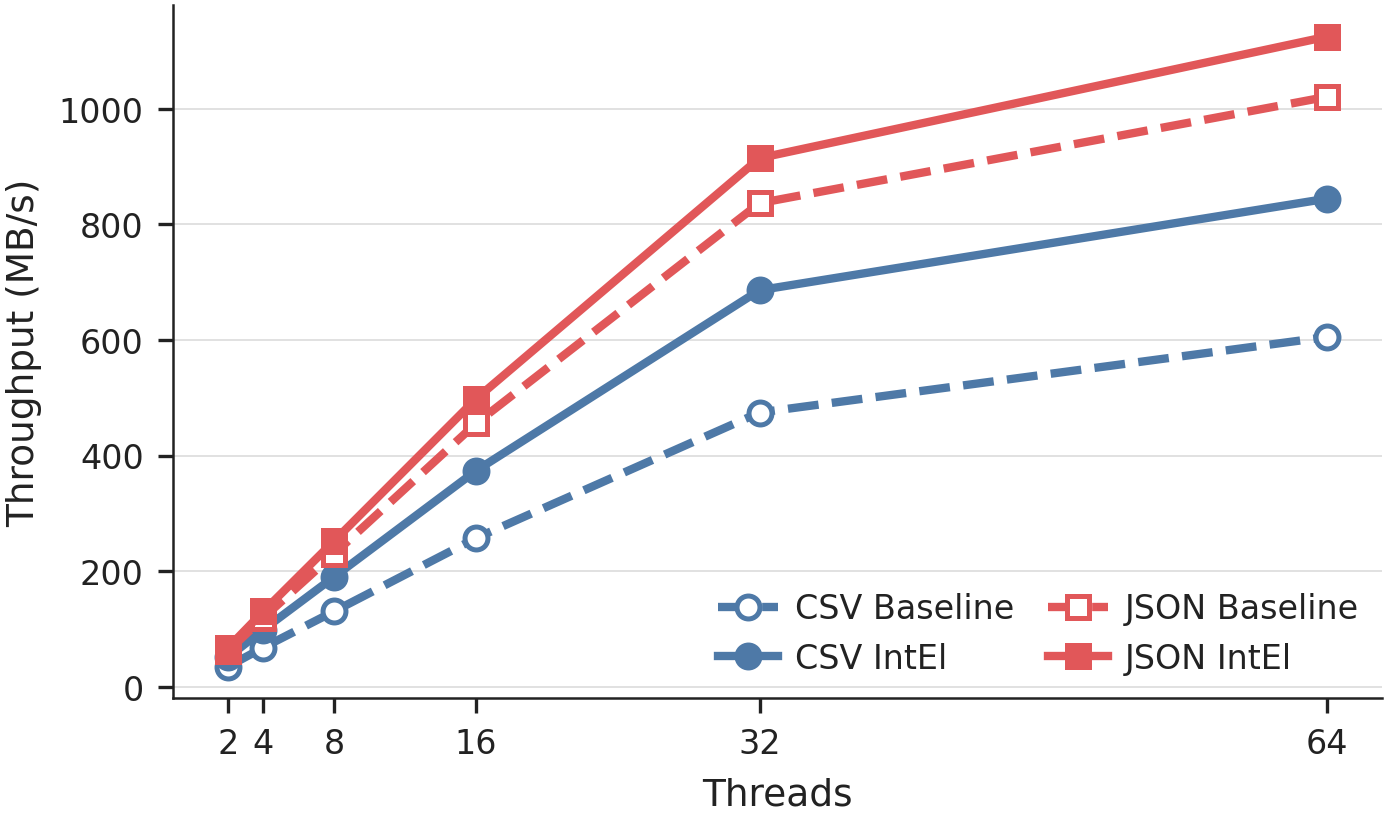

wrote plots/raw_comparison_line_throughput_q3.pdf


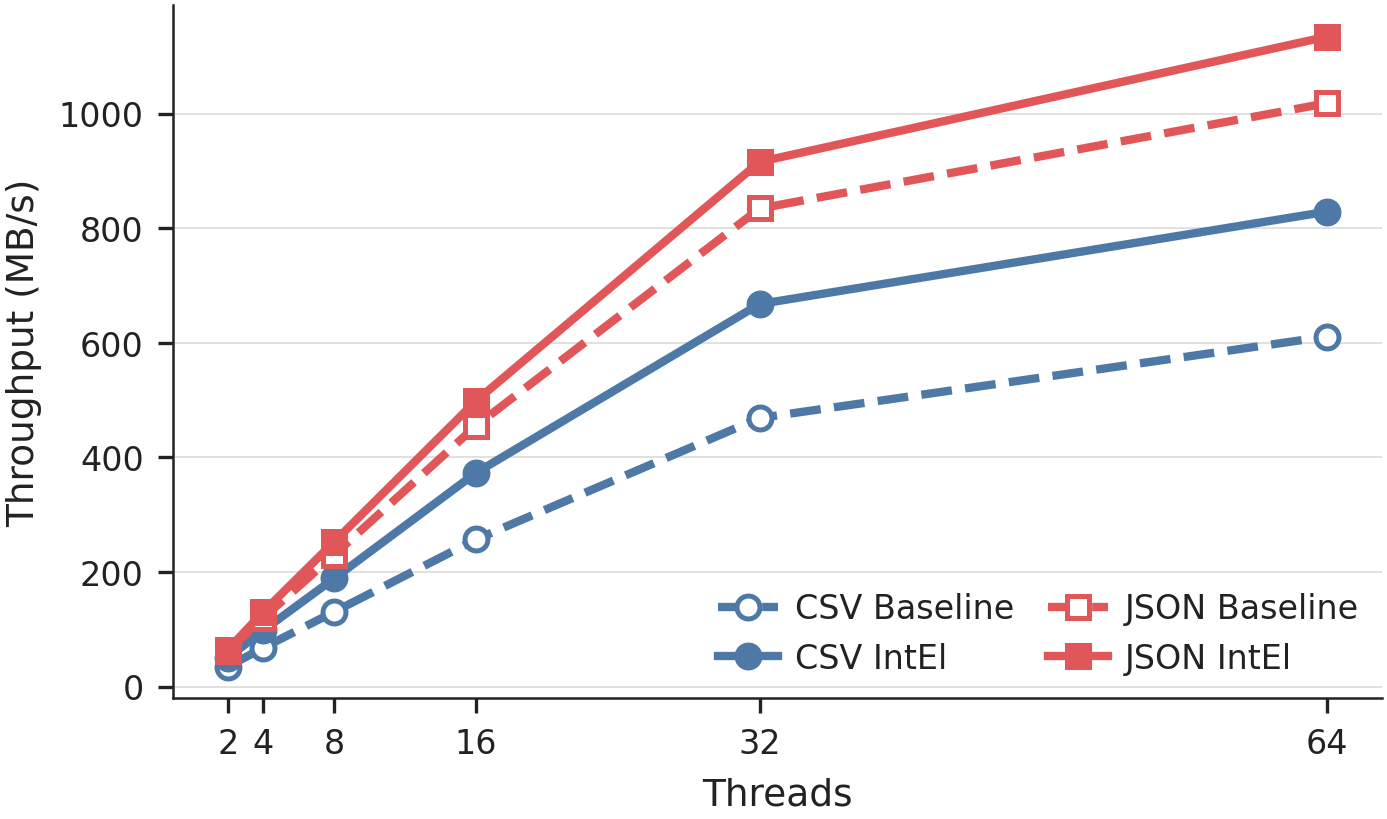

In [51]:
# Line plots: median throughput over thread count, one standalone plot per query
query_file_labels = {
    q: re.sub(r"[^a-z0-9]+", "_", query_labels[q].lower()).strip("_")
    for q in queries
}

suite_colors = {
    CSV_BASE_LABEL: "#4e79a7",
    CSV_PIE_LABEL: "#4e79a7",
    JSON_BASE_LABEL: "#e15759",
    JSON_PIE_LABEL: "#e15759",
}
suite_markers = {
    CSV_BASE_LABEL: "o",
    CSV_PIE_LABEL: "o",
    JSON_BASE_LABEL: "s",
    JSON_PIE_LABEL: "s",
}
suite_linestyles = {
    CSV_BASE_LABEL: "--",
    CSV_PIE_LABEL: "-",
    JSON_BASE_LABEL: "--",
    JSON_PIE_LABEL: "-",
}
suite_marker_faces = {
    CSV_BASE_LABEL: "white",
    CSV_PIE_LABEL: "#4e79a7",
    JSON_BASE_LABEL: "white",
    JSON_PIE_LABEL: "#e15759",
}

with mpl.rc_context(thesis_rc):
    for q in queries:
        fig, ax = plt.subplots(figsize=(5.2, 3.0), dpi=300)

        for suite in suite_order:
            vals = (
                df[(df["query"] == q) & (df["suite"] == suite)]
                .groupby("threads")["throughput_MBs"]
                .median()
                .reindex(thread_counts)
            )
            ax.plot(
                thread_counts,
                vals.to_numpy(dtype=float),
                marker=suite_markers[suite],
                markersize=5.5,
                linewidth=2.0,
                linestyle=suite_linestyles[suite],
                color=suite_colors[suite],
                markerfacecolor=suite_marker_faces[suite],
                markeredgecolor=suite_colors[suite],
                markeredgewidth=1.2,
                label=suite,
            )

        ax.set_xlabel("Threads")
        ax.set_ylabel("Throughput (MB/s)")
        ax.set_xticks(thread_counts)
        style_axis(ax)
        ax.legend(
            loc="lower right",
            ncol=2,
            columnspacing=1.0,
            handlelength=1.8,
            handletextpad=0.5,
            borderaxespad=0.3,
        )

        out = os.path.join(PLOTS_DIR, f"raw_comparison_line_throughput_{query_file_labels[q]}.pdf")
        fig.savefig(out)
        print(f"wrote {out}")
        plt.show()


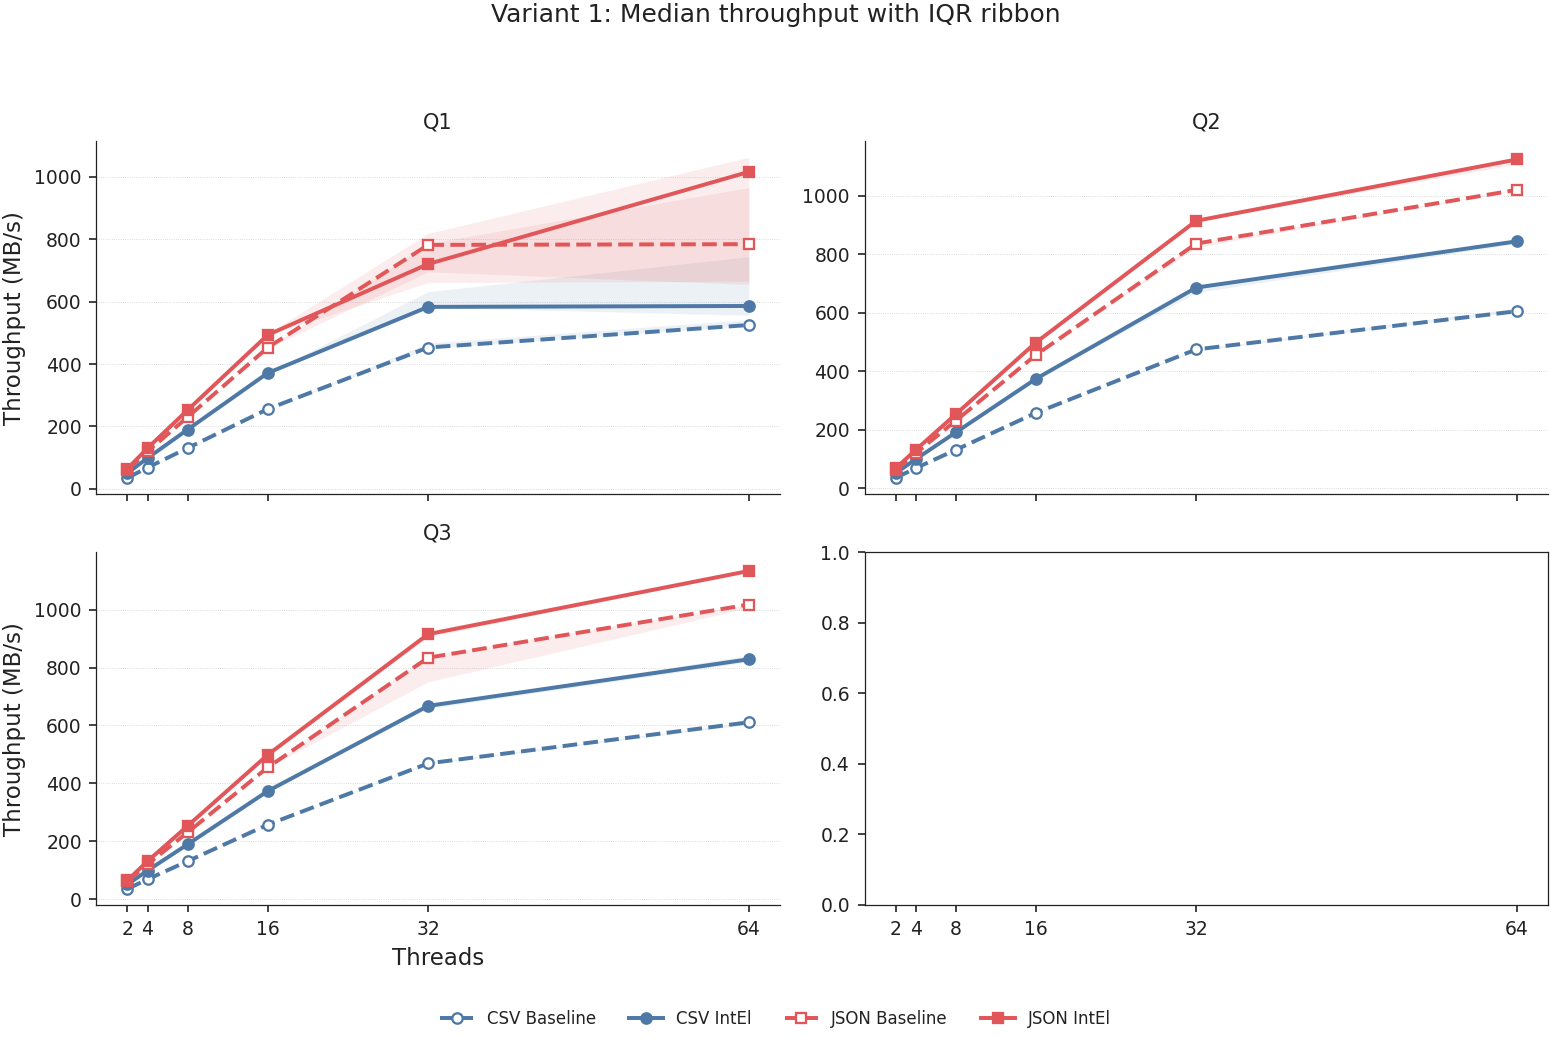

In [52]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

queries = sorted(df["query"].unique())
query_labels = {q: f"Q{i + 1}" for i, q in enumerate(queries)}
suites = SUITE_ORDER
thread_counts = sorted(df["threads"].unique())
suite_colors = {
    CSV_BASE_LABEL: "#4e79a7",
    CSV_PIE_LABEL: "#4e79a7",
    JSON_BASE_LABEL: "#e15759",
    JSON_PIE_LABEL: "#e15759",
}
suite_markers = {
    CSV_BASE_LABEL: "o",
    CSV_PIE_LABEL: "o",
    JSON_BASE_LABEL: "s",
    JSON_PIE_LABEL: "s",
}
suite_linestyles = {
    CSV_BASE_LABEL: "--",
    CSV_PIE_LABEL: "-",
    JSON_BASE_LABEL: "--",
    JSON_PIE_LABEL: "-",
}
suite_marker_faces = {
    CSV_BASE_LABEL: "white",
    CSV_PIE_LABEL: "#4e79a7",
    JSON_BASE_LABEL: "white",
    JSON_PIE_LABEL: "#e15759",
}

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 10,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

def style_axis(ax):
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Variant 1: median throughput with IQR ribbons in the same plot
stats = (
    df.groupby(["query", "suite", "threads"])["throughput_MBs"]
    .agg(q1=lambda s: s.quantile(0.25), median="median", q3=lambda s: s.quantile(0.75))
    .reset_index()
)

with mpl.rc_context(thesis_rc):
    fig, axes = plt.subplots(2, 2, figsize=(10.6, 6.8), sharex=True, squeeze=False)

    for idx, q in enumerate(queries):
        row, col = divmod(idx, 2)
        ax = axes[row][col]
        for suite in suites:
            subset = (
                stats[(stats["query"] == q) & (stats["suite"] == suite)]
                .set_index("threads")
                .reindex(thread_counts)
            )
            x = np.array(thread_counts)
            median = subset["median"].to_numpy(dtype=float)
            q1 = subset["q1"].to_numpy(dtype=float)
            q3 = subset["q3"].to_numpy(dtype=float)
            ax.fill_between(x, q1, q3, color=suite_colors[suite], alpha=0.10, linewidth=0)
            ax.plot(
                x, median,
                marker=suite_markers[suite], markersize=5.0,
                linewidth=1.9, linestyle=suite_linestyles[suite],
                color=suite_colors[suite],
                markerfacecolor=suite_marker_faces[suite],
                markeredgecolor=suite_colors[suite], markeredgewidth=1.1,
                label=suite,
            )
        ax.set_title(query_labels[q])
        ax.set_xticks(thread_counts)
        style_axis(ax)
        if row == 1:
            ax.set_xlabel("Threads")
        if col == 0:
            ax.set_ylabel("Throughput (MB/s)")

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle("Variant 1: Median throughput with IQR ribbon", y=1.01)
    fig.tight_layout(rect=(0, 0.04, 1, 0.97))
    plt.show()
